# Assignment 3: Class Activation Map
In this assignment we will use the [Class Activation Mapping Technique](http://cnnlocalization.csail.mit.edu/Zhou_Learning_Deep_Features_CVPR_2016_paper.pdf) to demonstrate that object specific spatial information is available in pre-trained image classification networks.

## Introduction:
The final output convolution layers of a trained image classification network contain detailed semantic information about the input image. These feature maps, although low resolution (e.g. 7 x 7) also contain spatial information about the location of the primary object in the image. In the class activation mapping technique we wish to extract this spatial information pertaining to the identified class and overlay this activation on the input image as shown in the figure below.

![](https://github.com/tonyscan6003/etivities/blob/main/cam_img.JPG?raw=true)

* Try to understand the algorithm and plan out the steps required before starting to code.
* The Resnet 50 model has been imported and outputs the last convolution layer and the logits (output of classifier)
* You can display your final results on a 4 x 4 plot.
 * Skeleton code is provided along with a function to unormalise the dataloader images for display.
 * The activation map using a heat map color scheme can be overlaid on the images using matplotlib "alpha" which sets the transparancy of the image e.g. `plt.imshow(class_act_map,cmap=plt.cm.jet,alpha=0.4)`























## HouseKeeping
  Import Packages, set batch size and Size of Images input to network.

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import time
import os
import numpy as np
import glob
import random
import torch
import torch.nn.functional as F
from torch import nn
from torchvision import datasets, models
from torchvision import utils
from torchvision.transforms import ToTensor, v2, Pad, Grayscale
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output


In [2]:
!pip install torchinfo
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 12.9 MB/s eta 0:00:00


In [3]:
# Global Variables
HW_trg =224

## Import Dataset

 For this notebook we will use the pytorch [ImageNett dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html) which contains a sub-set of the ImageNet test dataset with only 10 examples per class. This will be sufficient to demonstrate the Class Activation Mapping algorithm.

The transform is setup without data augmentation and with the required normalisation for the ResNet50 model.

In [4]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
imagenet_data = datasets.Imagenette('/root/INET',download=True,transform=transform)
data_loader = torch.utils.data.DataLoader(imagenet_data,
                                          batch_size=1,
                                          shuffle=True)

100%|██████████| 1.56G/1.56G [00:24<00:00, 63.5MB/s]


Plot a test image from the dataset. The image must be unnormalised and output in the correct form [H,W,C] for display by plt.imshow using `<unnormalise image function>`. (You can re-use this function later to unnormalise images that you will overlay the class activation maps onto.)

In [5]:

imagenette_dict={0:'Tench Fish',217:'English Springer',482:'Casette Player',
                491:'Chain Saw',497:'Church',566:'French Horn',
                 569:'Grabage Truck',571:'Gas Pump',574:'Golfball',
                 662:'Modem', 701:'Parachute',864:'Tow Truck', 867:'Trailer Truck'}
mean = [0.485, 0.456, 0.406]  # Example mean used for normalization
std = [0.229, 0.224, 0.225]   # Example std used for normalization

def unnormalize_image(image, mean, std):
    """
    Unnormalize a PyTorch image tensor.

    Args:
        image (torch.Tensor): The normalized image tensor of shape [C, H, W].
        mean (list or tuple): The mean used for normalization.
        std (list or tuple): The standard deviation used for normalization.

    Returns:
        torch.Tensor: The unnormalized image tensor.
    """
    # Remove the batch dimension
    image = image.squeeze(0)

    # Check if the image is in the shape [C, H, W]
    if image.dim() == 3:
        # Unnormalize the image
        for t, m, s in zip(image, mean, std):
            t.mul_(s).add_(m)
    else:
        raise ValueError("Expected image tensor of shape [C, H, W]")

    # Convert from [C, x, y] to [x, y, C]
    image = image.permute(1, 2, 0)

    return image

torch.Size([1, 3, 224, 224])


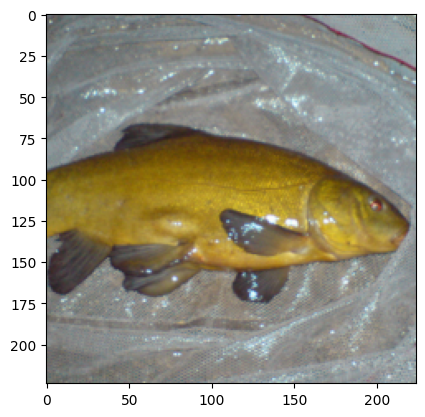

In [6]:
# Verity Dataloader & Image
dataiter = iter(data_loader)
z = next(dataiter)
print(np.shape(z[0]))

img=unnormalize_image(z[0],mean,std)
plt.imshow(img)


# Import Model

This assignment can be completed with CPU runtime as only inference from the model is required. The ResNet50 model is imported for this Assignment. As detailed in the paper a global average pooling layer conected to the classifier layer is required to work. The Resnet50 model satisfies this requirement (without needing modification & retraining)

In [7]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


ResNet50 Model is loaded & modified with [create_feature_extraction](https://pytorch.org/vision/stable/feature_extraction.html) to allow output of both logits and feature maps

In [8]:
# Load Model with weights
resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Obtain list of graph nodes
train_nodes, eval_nodes = get_graph_node_names(resnet50)
#print(train_nodes)

# Define Dictionary of output nodes
return_nodes={'layer4.2.conv3':'op_features','fc':'op_logits'}

# Create new model using the return nodes
model=create_feature_extractor(resnet50, return_nodes=return_nodes)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 74.8MB/s]


In [9]:
# Plot Model Summary
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Module: 1-5                            --                        --
│    └─Module: 2-1                       --                        --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

Test Passing data through model & verify outputs.

In [10]:
#pass data through model
out=model(z[0])
print([(k, v.shape) for k, v in out.items()])


[('op_features', torch.Size([1, 2048, 7, 7])), ('op_logits', torch.Size([1, 1000]))]


Obtain weights of classifier layer of model from state dictionary

In [11]:
sd = model.state_dict()
print(sd.keys())
print(np.shape((sd['fc.weight'])))

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.0.bn3.running_mean', 'layer1.0.bn3.running_var', 'layer1.0.bn3.num_batches_tracked', 'layer1.0.downsample.0.weight', 'layer1.0.downsample.1.weight', 'layer1.0.downsample.1.bias', 'layer1.0.downsample.1.running_mean', 'layer1.0.downsample.1.running_var', 'layer1.0.downsample.1.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.we

# Class Activion Mapping
You can implement the class activation mapping algorithm in the code cell below.



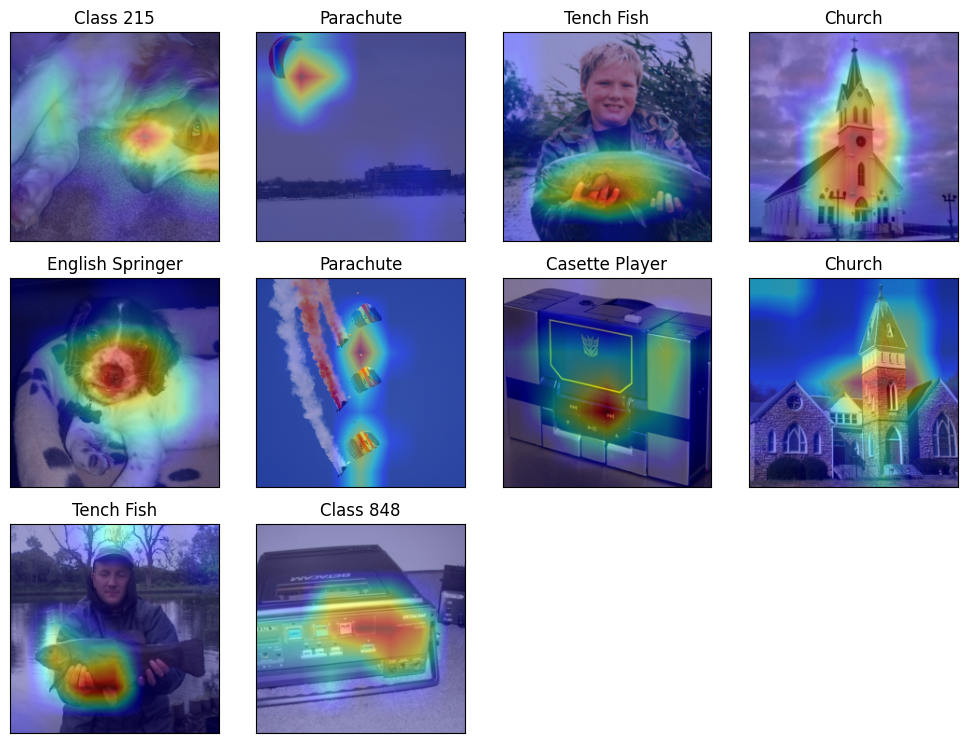

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize Figure
fig = plt.figure(figsize=(10, 10))

# Ensure model is eval mode to disable batch normalisation during inference.
model.eval()

# Iterate over the data_loader to produce a few examples
for i, (image, true_label) in enumerate(data_loader):
    if i >= 10:  # Limit to 10 examples for display
        break

    # Get model outputs
    outputs = model(image)
    features = outputs['op_features']  # (1, 2048, 7, 7)
    logits = outputs['op_logits']      # (1, 1000)

    # Get predicted class
    probabilities = F.softmax(logits, dim=1)
    max_prob, predicted_class_idx = torch.max(probabilities, 1)

    # Get weights for the predicted class from the classifier layer
    # The weights for the 'fc' layer are in sd['fc.weight'], shape [1000, 2048]
    classifier_weights = sd['fc.weight'][predicted_class_idx.item()] # shape [2048]

    # Calculate Class Activation Map
    # Squeeze the batch dimension from features to (2048, 7, 7)
    # Reshape features to (2048, 49) for matrix multiplication
    # Perform weighted sum: classifier_weights (1, 2048) * features_reshaped (2048, 49) -> (1, 49)
    # Then reshape to (7, 7)
    class_act_map = torch.matmul(classifier_weights, features.squeeze(0).view(features.shape[1], -1))
    class_act_map = class_act_map.reshape(features.shape[2], features.shape[3])

    # Apply ReLU
    class_act_map = F.relu(class_act_map)

    # Upsample the CAM to the original image size (HW_trg x HW_trg)
    # CAM is (7, 7), needs to be (1, 1, H, W) for F.interpolate
    act_map_us = F.interpolate(class_act_map.unsqueeze(0).unsqueeze(0), # Add batch and channel dimensions
                               size=(HW_trg, HW_trg),
                               mode='bilinear',
                               align_corners=False).squeeze() # Remove extra dimensions

    # Normalize the CAM to values between 0 and 1
    # Add a small epsilon to avoid division by zero if max and min are the same
    cam_min = act_map_us.min()
    cam_max = act_map_us.max()
    act_map_us_normalized = (act_map_us - cam_min) / (cam_max - cam_min + 1e-8)
    act_map_us_normalized = act_map_us_normalized.detach().cpu().numpy()

    # Plotting
    # unnormalize_image function expects image tensor [1, C, H, W], returns [H, W, C]
    original_img_display = unnormalize_image(image.clone(), mean, std)

    # Get label name for the predicted class
    predicted_label_name = imagenette_dict.get(predicted_class_idx.item(), f"Class {predicted_class_idx.item()}")

    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.title.set_text(predicted_label_name)
    ax.imshow(original_img_display.cpu().numpy())  # Display original unnormalized image
    ax.imshow(act_map_us_normalized, cmap=plt.cm.jet, alpha=0.4) # Overlay CAM

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Compare CAM for a single image against the top 5 class probabilities for same

Image tensor shape: torch.Size([1, 3, 224, 224])
True label: 5
Features shape: torch.Size([1, 2048, 7, 7])
Logits shape: torch.Size([1, 1000])
Top 5 probabilities: [0.4053651690483093, 0.0024842212442308664, 0.002225545234978199, 0.0016336690168827772, 0.0015684193931519985]
Top 5 class indices: [566, 432, 683, 546, 894]


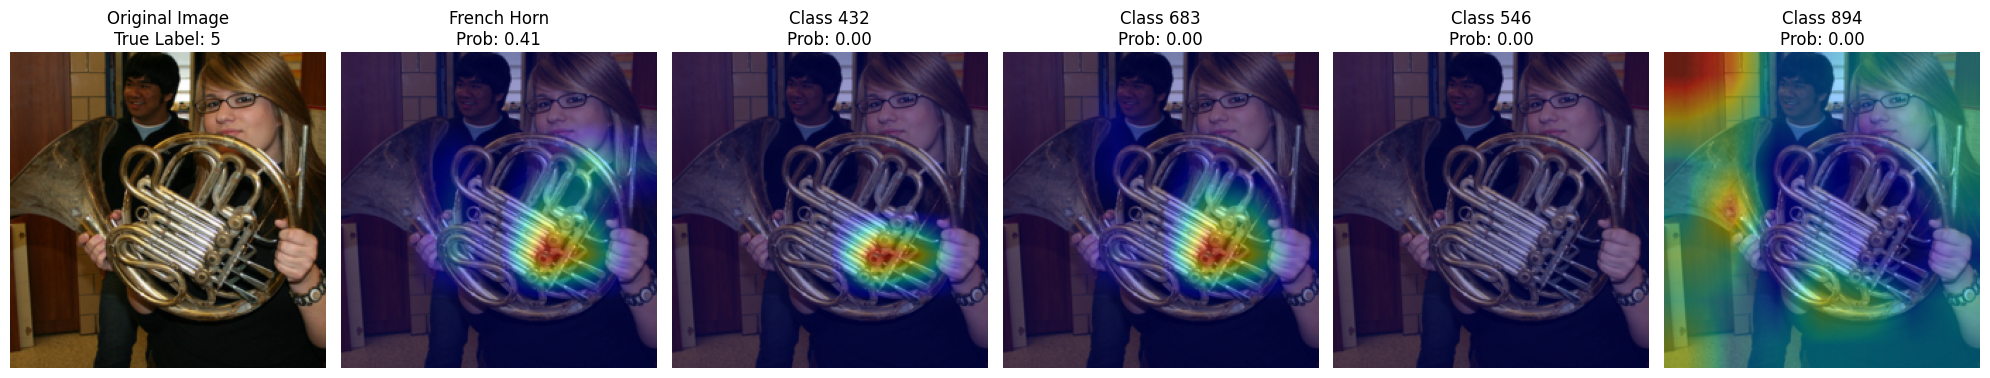

In [28]:
## Extract an image from the loader
dataiter = iter(data_loader)
image, true_label = next(dataiter)  # {1, 3, 224, 224]
print(f"Image tensor shape: {image.shape}")
print(f"True label: {true_label.item()}")

# Perform forward pass through ResNet50 model to obtain the final convolution features & logits
# for same

model.eval()
with torch.no_grad():
    outputs = model(image)
    features = outputs['op_features'] ## [1, 2048, 7, 7]
    logits = outputs['op_logits'] ## ([1, 1000]

print(f"Features shape: {features.shape}")
print(f"Logits shape: {logits.shape}")

probabilities = F.softmax(logits, dim=1)

# Get top 5 predicted classes and their probabilities
top5_prob, top5_indices = torch.topk(probabilities, 5)

print(f"Top 5 probabilities: {top5_prob.squeeze().tolist()}")
print(f"Top 5 class indices: {top5_indices.squeeze().tolist()}")


#Iterate through these top 5, generate the CAM for each and display side by side with the original

fig, axes = plt.subplots(1, 6, figsize=(20, 4)) # 1 for original + 5 for CAMs

# Ensure model is in evaluation mode
model.eval()

# Unnormalize the original image for display
original_img_display = unnormalize_image(image.clone(), mean, std).cpu().numpy()

# Display the original image in the first subplot
axes[0].imshow(original_img_display)
axes[0].set_title(f"Original Image\nTrue Label: {imagenette_dict.get(true_label.item(), str(true_label.item()))}")
axes[0].axis('off')

# Iterate over the top 5 predicted classes
for i in range(5):
    predicted_class_idx = top5_indices.squeeze()[i].item()
    predicted_prob = top5_prob.squeeze()[i].item()

    # Get weights for the current predicted class from the classifier layer
    classifier_weights = sd['fc.weight'][predicted_class_idx] # shape [2048]

    # Calculate Class Activation Map
    # Squeeze the batch dimension from features to (2048, 7, 7)
    # Reshape features to (2048, 49) for matrix multiplication
    # Perform weighted sum: classifier_weights (1, 2048) * features_reshaped (2048, 49) -> (1, 49)
    # Then reshape to (7, 7)
    class_act_map = torch.matmul(classifier_weights, features.squeeze(0).view(features.shape[1], -1))
    class_act_map = class_act_map.reshape(features.shape[2], features.shape[3])

    # Apply ReLU to get only positive activations
    class_act_map = F.relu(class_act_map)

    # Upsample the CAM to the original image size (HW_trg x HW_trg)
    # CAM is (7, 7), needs to be (1, 1, H, W) for F.interpolate, so use unsqueeze to upsample
    act_map_us = F.interpolate(class_act_map.unsqueeze(0).unsqueeze(0), # Add batch and channel dimensions
                               size=(HW_trg, HW_trg),
                               mode='bilinear',
                               align_corners=False).squeeze() # Remove extra dimensions

    # Normalize the CAM to values between 0 and 1 for better visualization
    cam_min = act_map_us.min()
    cam_max = act_map_us.max()
    act_map_us_normalized = (act_map_us - cam_min) / (cam_max - cam_min + 1e-8)
    act_map_us_normalized = act_map_us_normalized.detach().cpu().numpy()

    # Get label name for the predicted class
    predicted_label_name = imagenette_dict.get(predicted_class_idx, f"Class {predicted_class_idx}")

    # Plotting for each CAM
    ax = axes[i + 1]
    ax.imshow(original_img_display)
    ax.imshow(act_map_us_normalized, cmap=plt.cm.jet, alpha=0.4)
    ax.set_title(f"{predicted_label_name}\nProb: {predicted_prob:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


# Reflection.
The assignment involved calculating the Class Activation Mapping (CAM) which is a unseful visual aide to determine which parts of an image are most relevant to a particular class prediction.
Following the steps below :

1. Import Dataset: The ImageNette dataset (a subset of ImageNet) is loaded. Image transformations (resizing, center cropping, converting to tensor, and normalization specific to ResNet50) are applied. A DataLoader is then created to manage batching of the images.
2. We load the pretrained ImageNet ResNet50 model, and use the torchvision create_feature_extractor function to obtain the last CNN layer features and logits. In order to verify the output we plot a single image from the data_loader to validate the tensor shapes
3. The weights of the final fully connected (classifier) layer of the model are extracted from its state dictionary - these weights are used to calculate the CAM.
4. For each image of interest, we use the model to get the predicted class, and take the classifier weights corresponding to this. The CAM is generated as a weighted sum of the last convolutional layer's feature maps using these classifier weights.
5. This output is then Relu'ed to only use focus on the values providing positive feedback, and then upsampled using F.interpolate to the original image dimensions
6. The CAM is then normalized and overlaid on the original image, using a heatmap colormap and transparency to visually highlight the regions most indicative of the predicted class.
7. Top 5 CAMs - we took a sample image and generated the CAMs for each of the top 5 predicted classes, by extracting the top 5 class probabilities using the method outlined above. The were overlaid on the original image

### Observations
I was previously only normalising the output CAM, this was producing less focussed output due to including both +ve & -ve weights into the CAM, but after review (thanks to Melanie Walsh for her help with this), I'd missed Relu'ing the values to use the positive weights only which gave greater clarity in the image results.<br>
Also, within the Top 5 assessments, for some of the images, despite there being an order of magnitude variation between the top predicted class and the remaining, some of the images CAMs visually appear very close.